In [ ]:
# =====================================================
# PROJECT B - SAAS CHURN PREDICTOR
# Private Equity Due Diligence Tool
#
# Objective: Predict which SaaS customers are likely
# to churn - and explain why - to support PE
# acquisition due diligence decisions.
#
# Author:  Mark Wema
# Date:    June 2026
# Dataset: IBM Telco Customer Churn (Kaggle)
# Tools:   XGBoost, SHAP, Python
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print("Project B - SaaS Churn Predictor")
print("PE Due Diligence Tool")
print("Initialised.\n")

Project B - SaaS Churn Predictor
PE Due Diligence Tool
Initialised.



In [ ]:
# Loading the Telco Churn dataset directly from URL
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print(f"Dataset loaded: {df.shape[0]:,} customers, {df.shape[1]} features")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nChurn distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")

Dataset loaded: 7,043 customers, 21 features

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


Exploring to understand the business

In [ ]:
# Converting TotalCharges to numeric - it comes as string
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Convert Churn to binary
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

print("=== BUSINESS HEALTH SNAPSHOT ===\n")
print(f"Total customers:        {len(df):,}")
print(f"Churned customers:      {df['Churn_Binary'].sum():,}")
print(f"Retained customers:     {(df['Churn_Binary']==0).sum():,}")
print(f"Overall churn rate:     {df['Churn_Binary'].mean():.1%}")
print(f"\nAverage monthly charge: ${df['MonthlyCharges'].mean():.2f}")
print(f"Avg tenure (months):    {df['tenure'].mean():.1f}")
print(f"Avg total charges:      ${df['TotalCharges'].mean():.2f}")

# Revenue at risk from churners
churner_revenue = df[df['Churn_Binary']==1]['MonthlyCharges'].sum()
total_revenue   = df['MonthlyCharges'].sum()
print(f"\nMonthly revenue at risk: ${churner_revenue:,.0f}")
print(f"As % of total MRR:       {churner_revenue/total_revenue:.1%}")

=== BUSINESS HEALTH SNAPSHOT ===

Total customers:        7,043
Churned customers:      1,869
Retained customers:     5,174
Overall churn rate:     26.5%

Average monthly charge: $64.76
Avg tenure (months):    32.4
Avg total charges:      $2281.92

Monthly revenue at risk: $139,131
As % of total MRR:       30.5%


Churn Patterns By Segment

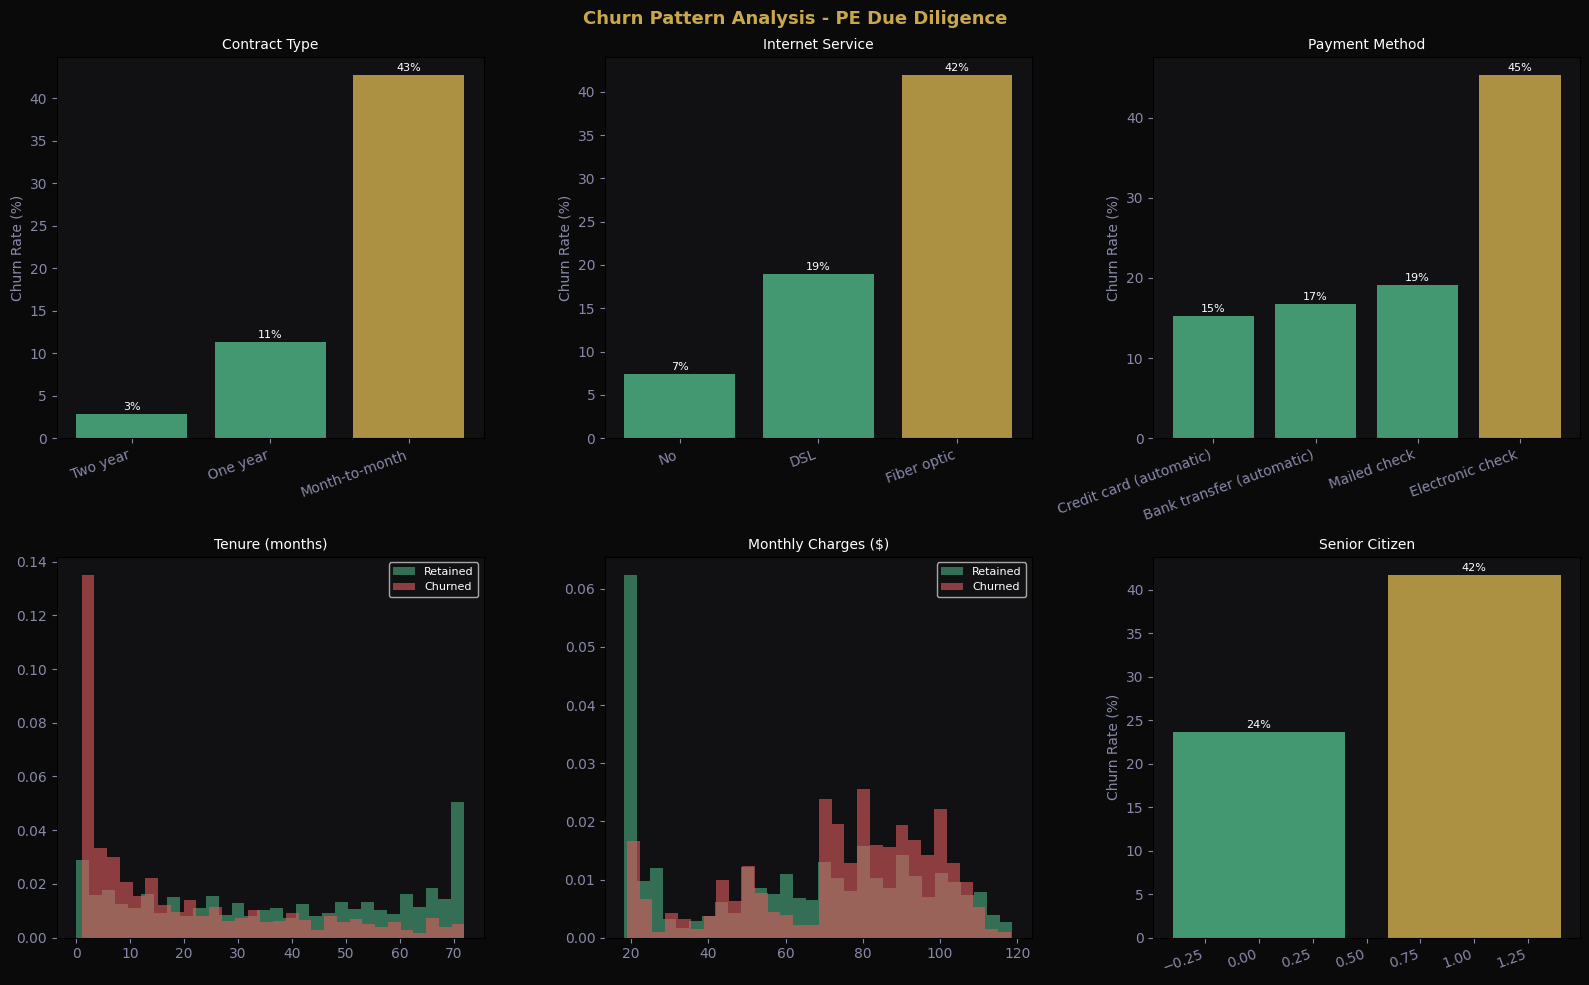

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor('#0A0A0B')

segments = [
    ('Contract',         'Contract Type'),
    ('InternetService',  'Internet Service'),
    ('PaymentMethod',    'Payment Method'),
    ('tenure',           'Tenure (months)'),
    ('MonthlyCharges',   'Monthly Charges ($)'),
    ('SeniorCitizen',    'Senior Citizen'),
]

colors = ['#E05C5C', '#4CAF82']

for idx, (col, title) in enumerate(segments):
    ax = axes[idx//3][idx%3]
    ax.set_facecolor('#111114')

    if df[col].dtype == 'object' or df[col].nunique() <= 2:
        # Categorical - bar chart of churn rate per category
        churn_by_cat = df.groupby(col)['Churn_Binary'].mean().sort_values()
        bars = ax.bar(churn_by_cat.index, churn_by_cat.values * 100,
                      color=['#4CAF82' if v < 0.3 else '#C9A84C'
                             if v < 0.5 else '#E05C5C'
                             for v in churn_by_cat.values],
                      alpha=0.85)
        for bar, val in zip(bars, churn_by_cat.values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.5,
                    f'{val:.0%}', ha='center',
                    color='white', fontsize=8)
        ax.set_ylabel('Churn Rate (%)', color='#8888AA')
        plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
    else:
        # Numeric - histogram by churn status
        for churn_val, color, label in [(0,'#4CAF82','Retained'),
                                         (1,'#E05C5C','Churned')]:
            ax.hist(df[df['Churn_Binary']==churn_val][col],
                    bins=30, alpha=0.6, color=color,
                    label=label, density=True)
        ax.legend(facecolor='#111114', labelcolor='white', fontsize=8)

    ax.set_title(title, color='white', fontsize=10)
    ax.tick_params(colors='#8888AA')

fig.suptitle('Churn Pattern Analysis - PE Due Diligence',
             color='#C9A84C', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Question Analysis
- **Overall Churn Rate**: The overall churn rate is **26.5%**. For a PE investor, this is generally considered a high churn rate for a SaaS business and would likely be a significant concern, as it indicates a substantial loss of customers over time.

- **Monthly Revenue at Risk**: Approximately **30.5%** of the total monthly recurring revenue (MRR) is at risk from churners. This is a substantial portion of revenue that could be lost if churn is not addressed.

- **Contract Type with Highest Churn Rate**: The **Month-to-month** contract type has the highest churn rate at **43%.** This makes intuitive sense because month-to-month contracts typically require less commitment from customers, making it easier for them to cancel their service compared to longer-term (one-year or two-year) contracts. Customers on these shorter contracts have more flexibility to switch providers.

- **Most Striking Pattern Across Segment Charts**: The most striking pattern is the significantly higher churn rates (around 40-45%) associated with a lack of commitment or a premium service/payment method. Specifically, customers with:

  - **Month-to-month contracts** (43% churn).
  - **Fiber optic internet service** (42% churn), which often comes with higher prices or expectations.
  - **Electronic check payment methods** (45% churn), which might correlate with less stable financial situations or a less integrated customer experience.

Additionally, **new customers** (low tenure) show a very high propensity to churn, as do **customers with higher monthly charges**. These factors suggest that a combination of customer commitment, the value perception of services, and initial customer experience are strong drivers of churn.

Feature Engineering for the Model

Translate these patterns into features XGBoost can learn from.

In [ ]:
# Encode categorical variables
df_model = df.copy()

# Drop customerID - not predictive
df_model.drop('customerID', axis=1, inplace=True)

# Binary columns - map Yes/No to 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService',
                'PaperlessBilling']
for col in binary_cols:
    df_model[col] = (df_model[col] == 'Yes').astype(int)

# Gender
df_model['gender'] = (df_model['gender'] == 'Male').astype(int)

# One-hot encode multi-category columns
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'
]

df_model = pd.get_dummies(df_model, columns=multi_cat_cols, drop_first=True)

# Target variable
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)
df_model.drop('Churn_Binary', axis=1, inplace=True, errors='ignore')

print(f"Final feature set: {df_model.shape[1]-1} features")
print(f"Total samples: {df_model.shape[0]:,}")
print(f"\nFeature names:")
print([c for c in df_model.columns if c != 'Churn'])

Final feature set: 30 features
Total samples: 7,043

Feature names:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


Engineering PE-Specific Features

Beyond raw columns, i will add features that capture business logic a PE analyst would think about:

In [ ]:
# Customer Lifetime Value proxy
df_model['CLV_proxy'] = df_model['MonthlyCharges'] * df_model['tenure']

# Average revenue per tenure month (efficiency signal)
df_model['Revenue_per_tenure'] = df_model['TotalCharges'] / (df_model['tenure'] + 1)

# Service adoption count — how many add-on services?
service_cols = [c for c in df_model.columns if any(
    s in c for s in ['OnlineSecurity_Yes', 'OnlineBackup_Yes',
                      'DeviceProtection_Yes', 'TechSupport_Yes',
                      'StreamingTV_Yes', 'StreamingMovies_Yes']
)]
df_model['Services_Adopted'] = df_model[service_cols].sum(axis=1)

# Tenure buckets - early-life vs mature customers
df_model['Is_New_Customer'] = (df_model['tenure'] <= 6).astype(int)
df_model['Is_Loyal_Customer'] = (df_model['tenure'] >= 48).astype(int)

print("PE-specific features added:")
print("  - CLV_proxy (lifetime value estimate)")
print("  - Revenue_per_tenure (efficiency)")
print("  - Services_Adopted (stickiness signal)")
print("  - Is_New_Customer (high-risk flag)")
print("  - Is_Loyal_Customer (low-risk flag)")

print(f"\nFinal shape: {df_model.shape}")

PE-specific features added:
  - CLV_proxy (lifetime value estimate)
  - Revenue_per_tenure (efficiency)
  - Services_Adopted (stickiness signal)
  - Is_New_Customer (high-risk flag)
  - Is_Loyal_Customer (low-risk flag)

Final shape: (7043, 36)


Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train):,} customers")
print(f"Test set:     {len(X_test):,} customers")
print(f"\nChurn rate in train: {y_train.mean():.1%}")
print(f"Churn rate in test:  {y_test.mean():.1%}")
print("\n(stratify=y ensures both sets have the same churn rate -")
print(" critical for imbalanced classification problems)")

Training set: 5,634 customers
Test set:     1,409 customers

Churn rate in train: 26.5%
Churn rate in test:  26.5%

(stratify=y ensures both sets have the same churn rate -
 critical for imbalanced classification problems)


Train XGBoost Model

In [ ]:
!pip install xgboost shap -q

In [ ]:
import xgboost as xgb
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, roc_curve
)

# Handle class imbalance — churners are ~26.5% of data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Evaluation
auc = roc_auc_score(y_test, y_proba)

print("=== MODEL PERFORMANCE ===\n")
print(f"ROC-AUC Score: {auc:.3f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Retained','Churned'])}")

=== MODEL PERFORMANCE ===

ROC-AUC Score: 0.841

              precision    recall  f1-score   support

    Retained       0.91      0.73      0.81      1035
     Churned       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



 Visualising Model Performance

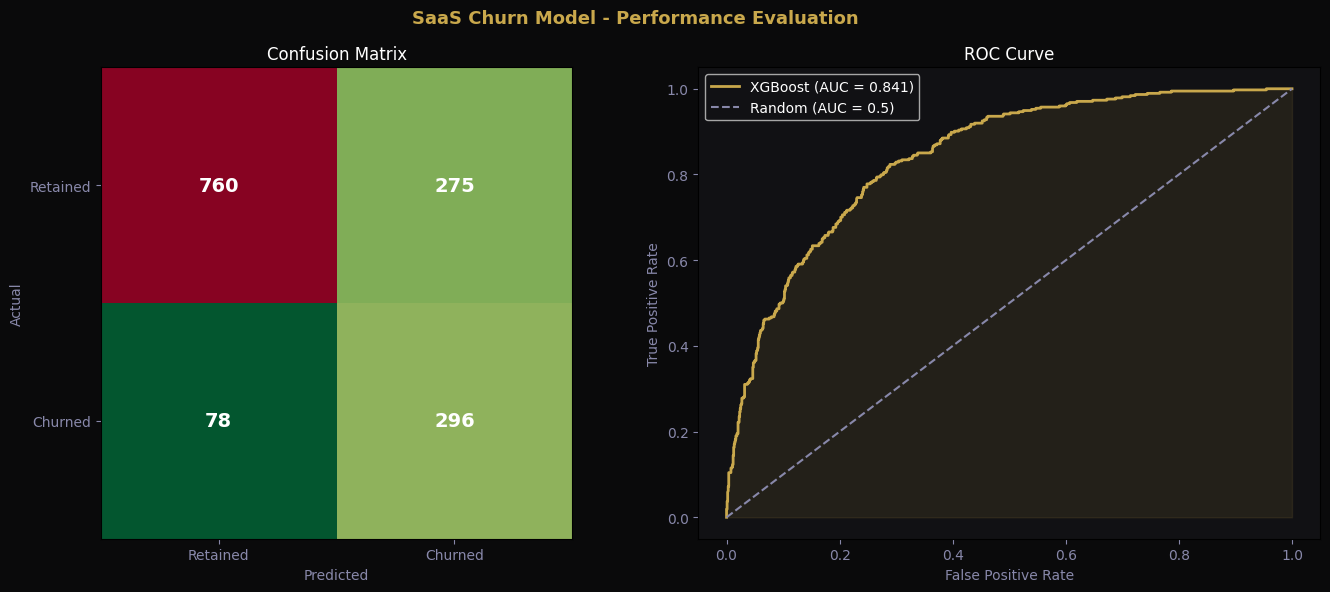

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0A0A0B')

# -- Confusion Matrix
ax1 = axes[0]
cm = confusion_matrix(y_test, y_pred)
im = ax1.imshow(cm, cmap='RdYlGn_r', alpha=0.8)

labels = ['Retained', 'Churned']
ax1.set_xticks([0,1]); ax1.set_yticks([0,1])
ax1.set_xticklabels(labels); ax1.set_yticklabels(labels)

for i in range(2):
    for j in range(2):
        ax1.text(j, i, f'{cm[i,j]:,}',
                ha='center', va='center',
                color='white', fontsize=14, fontweight='bold')

ax1.set_facecolor('#111114')
ax1.set_title('Confusion Matrix', color='white', fontsize=12)
ax1.set_xlabel('Predicted', color='#8888AA')
ax1.set_ylabel('Actual', color='#8888AA')
ax1.tick_params(colors='#8888AA')

# -- ROC Curve
ax2 = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax2.plot(fpr, tpr, color='#C9A84C', linewidth=2,
         label=f'XGBoost (AUC = {auc:.3f})')
ax2.plot([0,1], [0,1], color='#8888AA',
         linestyle='--', label='Random (AUC = 0.5)')
ax2.fill_between(fpr, tpr, alpha=0.1, color='#C9A84C')

ax2.set_facecolor('#111114')
ax2.set_title('ROC Curve', color='white', fontsize=12)
ax2.set_xlabel('False Positive Rate', color='#8888AA')
ax2.set_ylabel('True Positive Rate', color='#8888AA')
ax2.tick_params(colors='#8888AA')
ax2.legend(facecolor='#111114', labelcolor='white')

plt.suptitle('SaaS Churn Model - Performance Evaluation',
             color='#C9A84C', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

- **ROC-AUC Score:** The model achieved an ROC-AUC score of 0.841. This is generally considered a strong score, indicating that the model has a good ability to distinguish between churners and non-churners across various classification thresholds.

- **Confusion Matrix - Identified vs. Missed Churners:**

  - The model correctly identified 296 churners (True Positives).
  - The model missed 78 churners (False Negatives), meaning these customers churned but the model predicted they would be retained.
- Recall for the Churned Class: The recall for the churned class is 79% (296 / (296 + 78) = 0.79). A PE firm would care more about recall than overall accuracy in this context because:

  - Minimizing Missed Churners: High recall means the model is good at catching most of the actual churners. For a PE firm conducting due diligence, it's crucial to identify as many potential churners as possible to accurately assess the risk and potential revenue loss. Missing a churner (false negative) could lead to an overestimation of the customer base's stability and future revenue.
  - Proactive Intervention: By identifying most churners, the firm can potentially implement retention strategies or adjust their valuation models more accurately.
- scale_pos_weight Purpose: The scale_pos_weight parameter was used to address the problem of class imbalance. In this dataset, churners (the positive class) make up only 26.5% of the data, while retained customers (the negative class) make up 73.5%. This imbalance means:

  - Bias towards Majority Class: A model might learn to simply predict the majority class (retained) most of the time, leading to high overall accuracy but poor performance (especially low recall) on the minority class (churners).
  - Why it Matters Here: For a PE firm, correctly identifying churners is critical due to the revenue at risk. scale_pos_weight assigns a higher penalty to misclassifying the minority class (churners) during training. This forces the model to pay more attention to the churners, helping it to improve its ability to predict them, which directly improves recall for the churned class, a key metric for this business problem.

**SHAP: Explaining The Model's Decisions**

This is the step that transforms your model from "a black box that predicts churn" into "a tool a PE partner can trust and act on."

SHAP (SHapley Additive exPlanations) answers: for any individual prediction, which features pushed it toward churn and by how much?

In [ ]:
import shap

# Create explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated.")
print(f"Shape: {shap_values.shape}")
print("\nEach value represents how much that feature")
print("pushed an individual prediction toward churn (+)")
print("or toward retention (-)")

SHAP values calculated.
Shape: (1409, 35)

Each value represents how much that feature
pushed an individual prediction toward churn (+)
or toward retention (-)


 Global Feature Importance

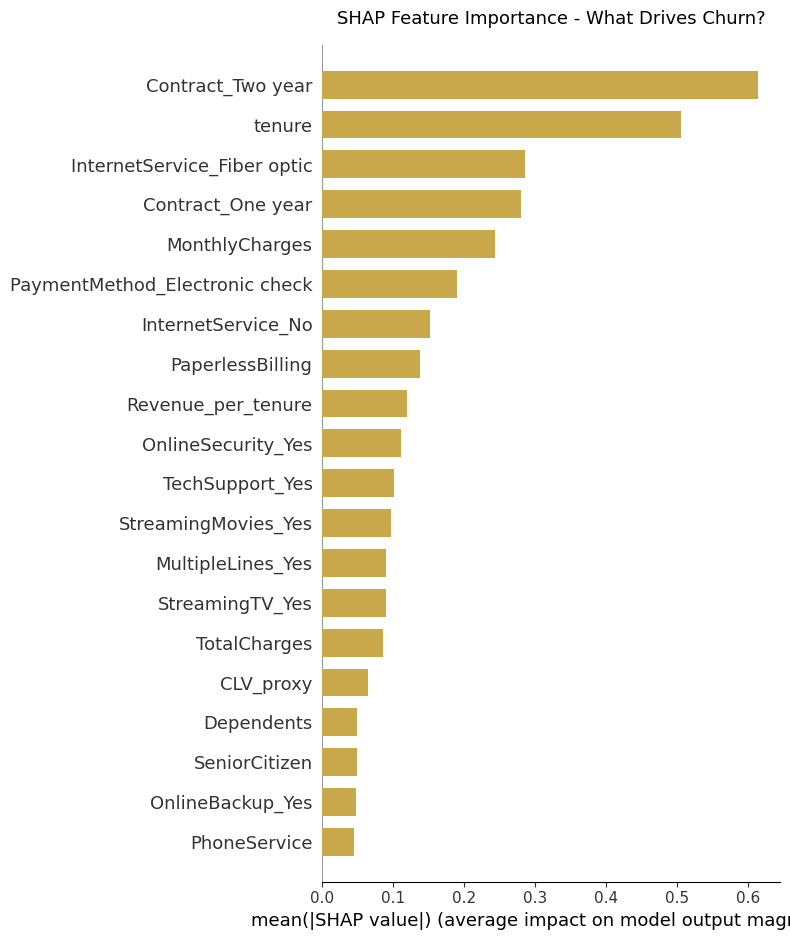

In [ ]:
# Summary plot - which features matter most overall?
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test,
    plot_type="bar",
    show=False,
    color='#C9A84C'
)
plt.title('SHAP Feature Importance - What Drives Churn?',
          fontsize=13, color='black', pad=15)
plt.tight_layout()
plt.show()

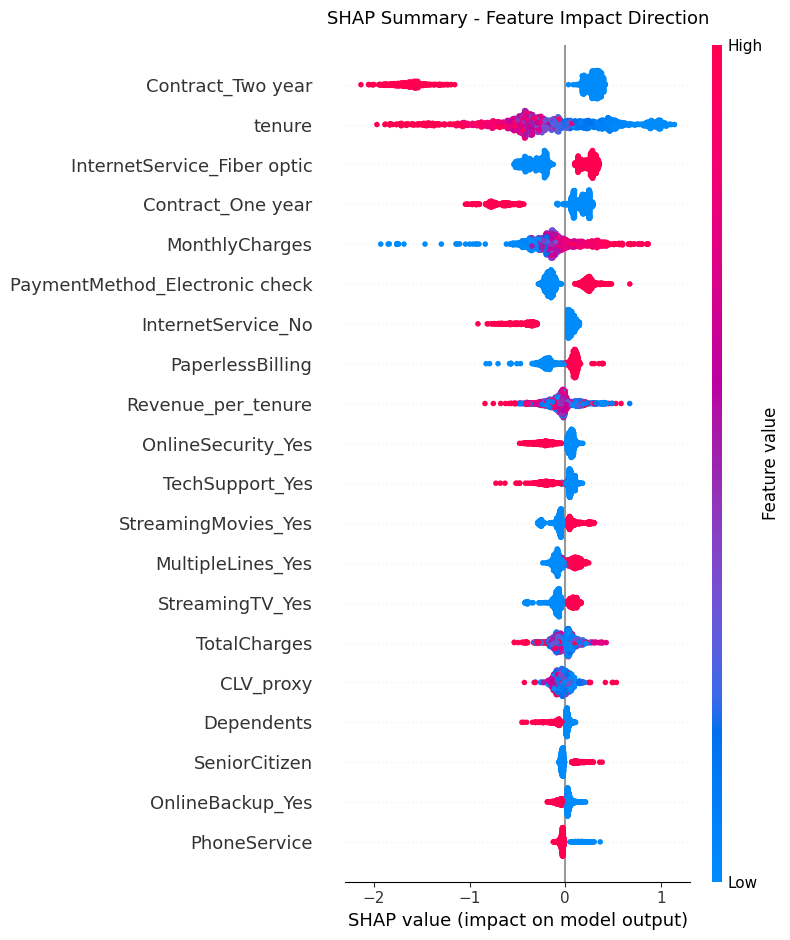

In [ ]:
# Detailed summary - direction AND magnitude
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test,
    show=False
)
plt.title('SHAP Summary - Feature Impact Direction',
          fontsize=13, color='black', pad=15)
plt.tight_layout()
plt.show()

- Each dot is one customer
- Red = high feature value, Blue = low feature value
- Right of center = pushes toward churn, Left = pushes toward retention
- Spread shows how much that feature varies in impact across customers

Explain an Individual Customer

This is what makes SHAP powerful for due diligence - you can explain any specific customer's risk.

=== INDIVIDUAL CUSTOMER EXPLANATION ===

Customer churn probability: 96.7%
Actual outcome: Churned


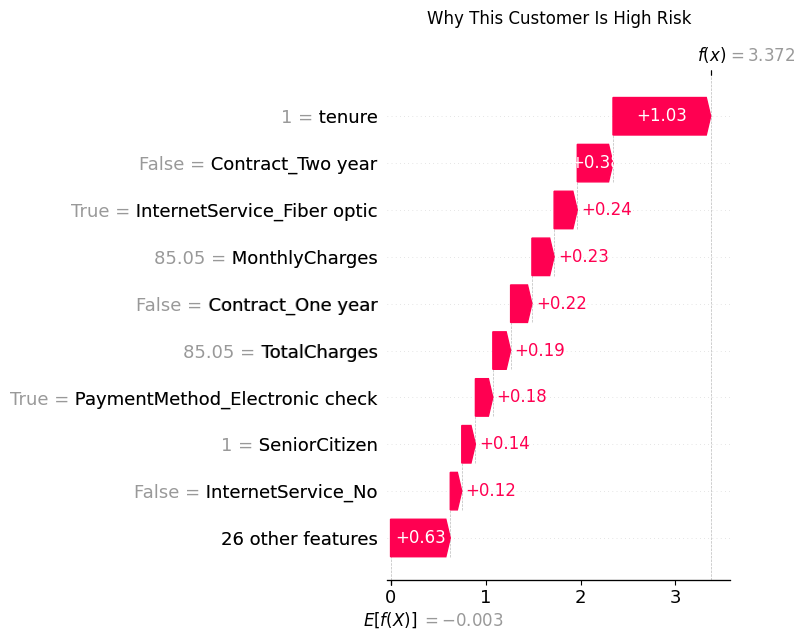

In [ ]:
# Pick a high-risk customer
high_risk_idx = y_proba.argsort()[-1]  # highest churn probability

print(f"=== INDIVIDUAL CUSTOMER EXPLANATION ===\n")
print(f"Customer churn probability: {y_proba[high_risk_idx]:.1%}")
print(f"Actual outcome: {'Churned' if y_test.iloc[high_risk_idx]==1 else 'Retained'}")

# Waterfall plot - shows exactly why THIS customer is high risk
plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[high_risk_idx],
        feature_names=X_test.columns.tolist()
    ),
    show=False,
    max_display=10
)
plt.title('Why This Customer Is High Risk',
          fontsize=12, color='black', pad=15)
plt.tight_layout()
plt.show()

Portfolio-Level Risk Segmentation

Now we turn individual predictions into a portfolio-level due diligence tool

In [ ]:
# Add predictions back to test set
results = X_test.copy()
results['Actual_Churn'] = y_test.values
results['Churn_Probability'] = y_proba
results['Predicted_Churn'] = y_pred

# Risk segments
def risk_segment(prob):
    if prob >= 0.7:
        return 'CRITICAL'
    elif prob >= 0.5:
        return 'HIGH'
    elif prob >= 0.3:
        return 'MEDIUM'
    else:
        return 'LOW'

results['Risk_Segment'] = results['Churn_Probability'].apply(risk_segment)

# Revenue at risk by segment
results['Monthly_Revenue'] = results['MonthlyCharges']

segment_summary = results.groupby('Risk_Segment').agg(
    Customers=('Churn_Probability', 'count'),
    Avg_Churn_Prob=('Churn_Probability', 'mean'),
    Monthly_Revenue=('Monthly_Revenue', 'sum'),
    Actual_Churners=('Actual_Churn', 'sum')
).round(3)

# Order segments logically
segment_order = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']
segment_summary = segment_summary.reindex(segment_order)

print("=== PORTFOLIO RISK SEGMENTATION ===\n")
print(segment_summary)

print(f"\nTotal customers analysed: {len(results):,}")
print(f"Total monthly revenue:    ${results['Monthly_Revenue'].sum():,.0f}")
print(f"\nCRITICAL + HIGH risk revenue: "
      f"${segment_summary.loc[['CRITICAL','HIGH'], 'Monthly_Revenue'].sum():,.0f}")
print(f"As % of total: "
      f"{segment_summary.loc[['CRITICAL','HIGH'], 'Monthly_Revenue'].sum() / results['Monthly_Revenue'].sum():.1%}")

=== PORTFOLIO RISK SEGMENTATION ===

              Customers  Avg_Churn_Prob  Monthly_Revenue  Actual_Churners
Risk_Segment                                                             
CRITICAL            335           0.819          26014.8              214
HIGH                236           0.607          16684.6               82
MEDIUM              199           0.393          14065.2               43
LOW                 639           0.103          33536.6               35

Total customers analysed: 1,409
Total monthly revenue:    $90,301

CRITICAL + HIGH risk revenue: $42,699
As % of total: 47.3%


Visualise The Risk Portfolio

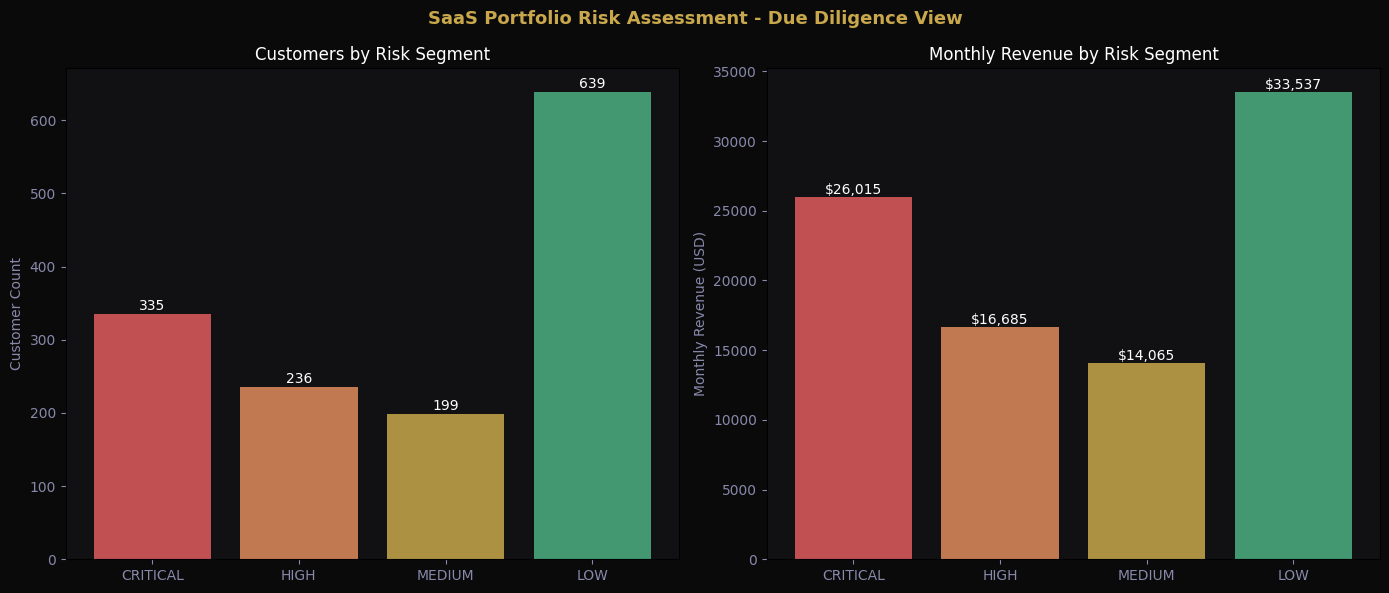

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0A0A0B')

risk_colors = {
    'CRITICAL': '#E05C5C',
    'HIGH':     '#E08C5C',
    'MEDIUM':   '#C9A84C',
    'LOW':      '#4CAF82'
}

# -- Customer count by segment
ax1 = axes[0]
counts = segment_summary['Customers']
bars = ax1.bar(counts.index, counts.values,
               color=[risk_colors[s] for s in counts.index],
               alpha=0.85)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             f'{val:,}', ha='center', color='white', fontsize=10)
ax1.set_facecolor('#111114')
ax1.set_title('Customers by Risk Segment', color='white', fontsize=12)
ax1.set_ylabel('Customer Count', color='#8888AA')
ax1.tick_params(colors='#8888AA')

# -- Revenue at risk by segment
ax2 = axes[1]
revenue = segment_summary['Monthly_Revenue']
bars2 = ax2.bar(revenue.index, revenue.values,
                color=[risk_colors[s] for s in revenue.index],
                alpha=0.85)
for bar, val in zip(bars2, revenue.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
             f'${val:,.0f}', ha='center', color='white', fontsize=10)
ax2.set_facecolor('#111114')
ax2.set_title('Monthly Revenue by Risk Segment', color='white', fontsize=12)
ax2.set_ylabel('Monthly Revenue (USD)', color='#8888AA')
ax2.tick_params(colors='#8888AA')

plt.suptitle('SaaS Portfolio Risk Assessment - Due Diligence View',
             color='#C9A84C', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Question Analysis
- **Top 3 features driving churn predictions globally:** According to the SHAP Feature Importance plot, the top 3 features driving churn are:

  1. Contract_Two year
  2. tenure
  3. InternetService_Fiber optic
- **Specific factors pushed the individual high-risk customer's churn probability up:** For the individual high-risk customer, the factors that pushed their churn probability up significantly were tenure (low tenure), InternetService_Fiber optic, MonthlyCharges, Contract_One year (absence of a one-year contract), and PaymentMethod_Electronic check.

- **Percentage of monthly revenue in CRITICAL + HIGH risk segments:** Approximately 47.3% of the total monthly revenue sits in the CRITICAL + HIGH risk segments.

- **One-sentence headline finding for a PE associate:** "The target SaaS company exhibits a high churn rate of 26.5%, with nearly half of its monthly recurring revenue (47.3%) at critical or high risk of churn, primarily driven by customer tenure, contract type, and internet service, indicating significant post-acquisition retention challenges and potential revenue leakage."